Xử lí dữ liệu 

In [ ]:
!/home/jupyter/tuandm/Swin-Unet/venv/bin/pip install ipykernel

488.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


494.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Installed kernelspec swin-unet-venv in /root/.local/share/jupyter/kernels/swin-unet-venv


In [13]:
!/home/jupyter/tuandm/Swin-Unet/venv/bin/python -m ipykernel install --user --name=swin-unet-venv --display-name="Python 3.10 (Swin-Unet)"

522.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Installed kernelspec swin-unet-venv in /root/.local/share/jupyter/kernels/swin-unet-venv


In [2]:
!/home/jupyter/tuandm/Swin-Unet/venv/bin/python -V
!pip install matplotlib

Python 3.10.20


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.3 MB/s  0:00:01m0:00:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 8.2 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


Dữ liệu ban đầu


🔍 [Slice 50] Thống kê diện tích:
   - 1. Aorta (Động mạch chủ): 485 pixels
   - 3. Left Kidney (Thận trái): 3482 pixels
   - 4*. Right Kidney (Thận phải): 2994 pixels
   - 6*. Pancreas (Tụy): 874 pixels
   - 7. Spleen (Lách): 3724 pixels

🔍 [Slice 85] Thống kê diện tích:
   - 1. Aorta (Động mạch chủ): 943 pixels
   - 5. Liver (Gan): 32733 pixels
   - 8. Stomach (Dạ dày): 3619 pixels

🔍 [Slice 100] Thống kê diện tích:
   - 1. Aorta (Động mạch chủ): 953 pixels
   - 5. Liver (Gan): 885 pixels


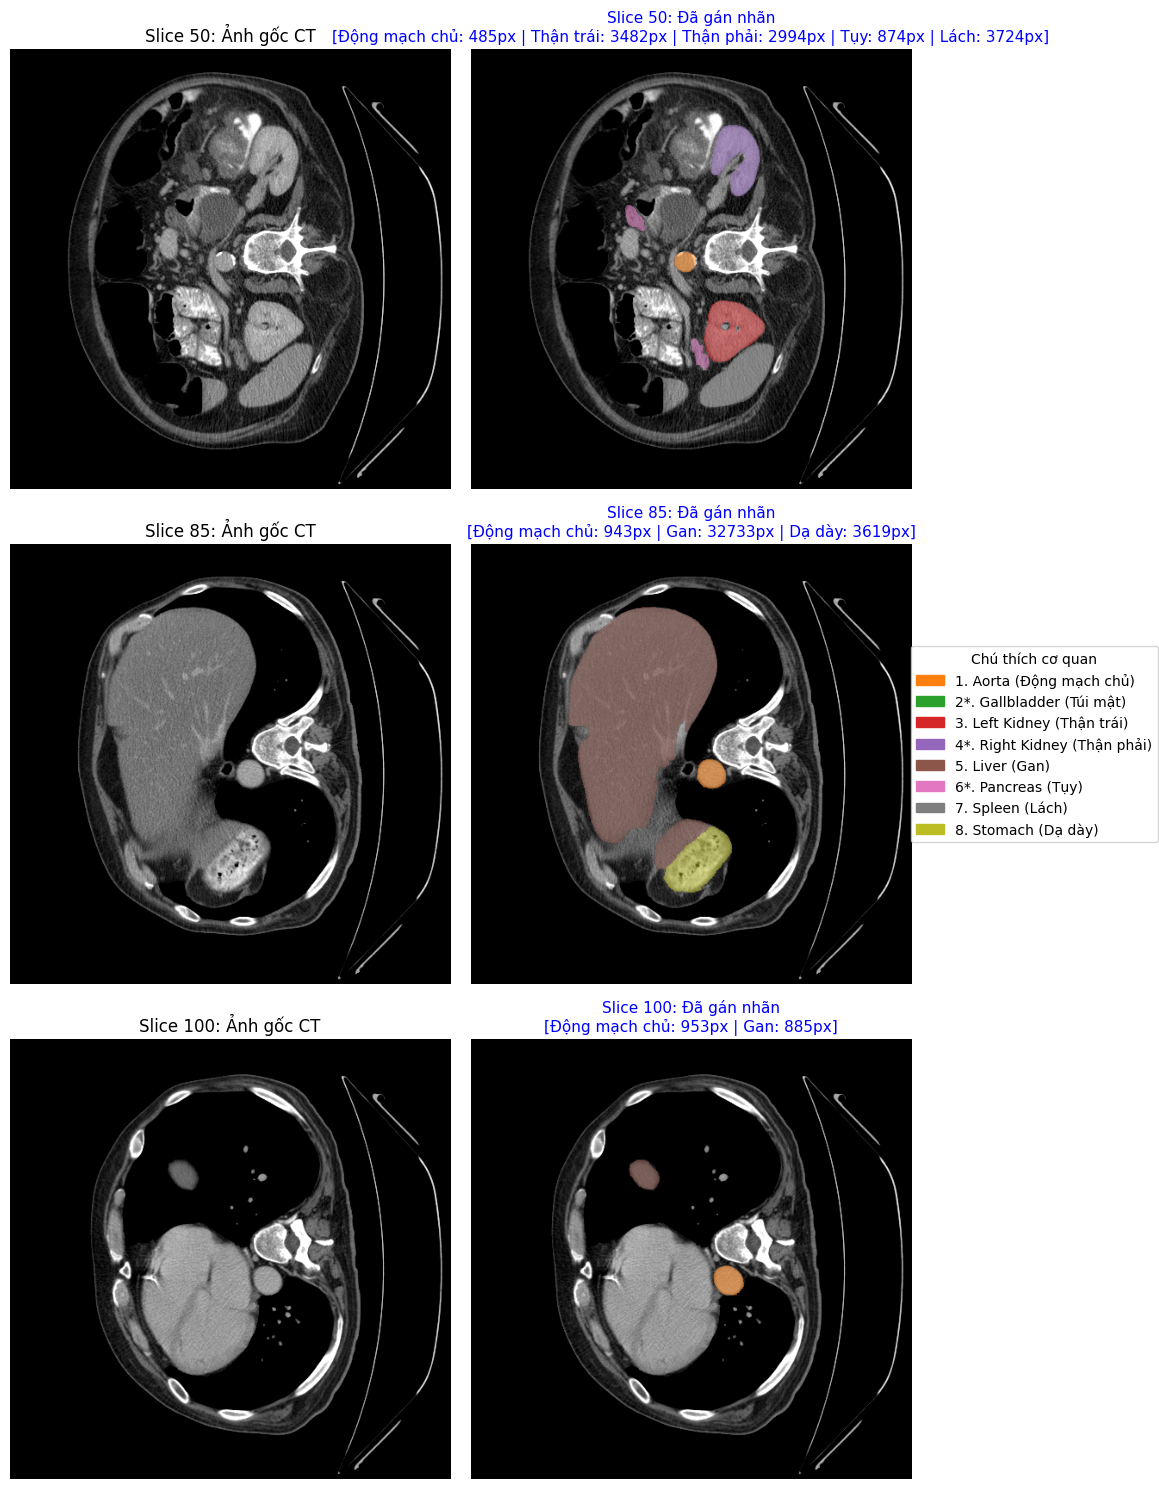

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# 1. Cấu hình
case_id = "case0005"
data_dir = "/home/jupyter/tuandm/Swin-Unet/data/Synapse/train_npz/"
# Chọn 3 lát cắt tiêu biểu để xem (tổng 6 hình cho vừa màn hình)
slices_to_show = [50, 85, 100] 

# Định nghĩa bảng màu và tên bộ phận
label_names = {
    1: "1. Aorta (Động mạch chủ)",
    2: "2*. Gallbladder (Túi mật)",
    3: "3. Left Kidney (Thận trái)",
    4: "4*. Right Kidney (Thận phải)",
    5: "5. Liver (Gan)",
    6: "6*. Pancreas (Tụy)",
    7: "7. Spleen (Lách)",
    8: "8. Stomach (Dạ dày)"
}

# 2. Thiết lập khung hình: Số hàng = số slice, Số cột = 2
n_slices = len(slices_to_show)
fig, axes = plt.subplots(n_slices, 2, figsize=(12, 5 * n_slices))
# Nếu chỉ xem 1 ảnh, axes sẽ là mảng 1D, ta ép về 2D để code không lỗi
if n_slices == 1:
    axes = np.expand_dims(axes, axis=0)
    
cmap = plt.get_cmap('tab10')

for i, slice_num in enumerate(slices_to_show):
    file_name = f"{case_id}_slice{slice_num:03d}.npz"
    file_path = os.path.join(data_dir, file_name)
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy {file_name}")
        continue

    # Load dữ liệu
    data = np.load(file_path)
    img = data['image'] if 'image' in data.files else data['data']
    lbl = data['label'] if 'label' in data.files else data['seg']
    
    # --- MỚI: TÍNH TOÁN VÀ ĐẾM SỐ PIXEL ---
    unique_classes, counts = np.unique(lbl, return_counts=True)
    pixel_texts = []
    
    print(f"\n🔍 [Slice {slice_num}] Thống kê diện tích:")
    for cls, count in zip(unique_classes, counts):
        if cls == 0: 
            continue # Bỏ qua nền đen (background)
            
        name = label_names.get(cls, f"Class {cls}")
        # Lấy tên tiếng Việt trong ngoặc để hiển thị trên ảnh cho ngắn gọn (VD: "Gan")
        short_name = name.split('(')[-1].replace(')', '') if '(' in name else name
        
        pixel_texts.append(f"{short_name}: {count}px")
        print(f"   - {name}: {count} pixels")

    # Gộp thành 1 chuỗi để hiển thị lên tiêu đề ảnh (VD: "Gan: 4500px | Lách: 1200px")
    info_str = " | ".join(pixel_texts) if pixel_texts else "Không có nội tạng nào"

    # --- Cột 1: Ảnh gốc ---
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Slice {slice_num}: Ảnh gốc CT")
    axes[i, 0].axis('off')
    
    # --- Cột 2: Ảnh Overlay ---
    axes[i, 1].imshow(img, cmap='gray')
    masked_lbl = np.ma.masked_where(lbl == 0, lbl)
    axes[i, 1].imshow(masked_lbl, cmap=cmap, alpha=0.5, vmin=0, vmax=10)
    
    # Gắn chuỗi info_str chứa số pixel vào tiêu đề, cho màu xanh nổi bật
    axes[i, 1].set_title(f"Slice {slice_num}: Đã gán nhãn\n[{info_str}]", fontsize=11, color='blue')
    axes[i, 1].axis('off')

# 3. Tạo Legend chung bên phải
unique_all = list(label_names.keys())
patches = [mpatches.Patch(color=cmap(v/10.0), label=label_names[v]) for v in unique_all]
fig.legend(handles=patches, loc='center right', borderaxespad=0.1, title="Chú thích cơ quan")

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Chừa khoảng trống bên phải (15%) cho Legend
plt.show()


📊 THỐNG KÊ SỐ PIXEL (LÁT CẮT HIỆN TẠI)
Cơ quan                   | Bác sĩ (GT)  | AI (Pred)    | Lệch      
------------------------------------------------------------
Aorta (ĐM chủ)            | 590          | 629          | +39       
Gallbladder (Túi mật)*    | 0            | 33           | +33       
Right Kidney (Thận phải)* | 407          | 291          | -116      
Liver (Gan)               | 22461        | 23299        | +838      
Pancreas (Tụy)*           | 302          | 250          | -52       
Spleen (Lách)             | 6745         | 6671         | -74       
Stomach (Dạ dày)          | 15715        | 15740        | +25       



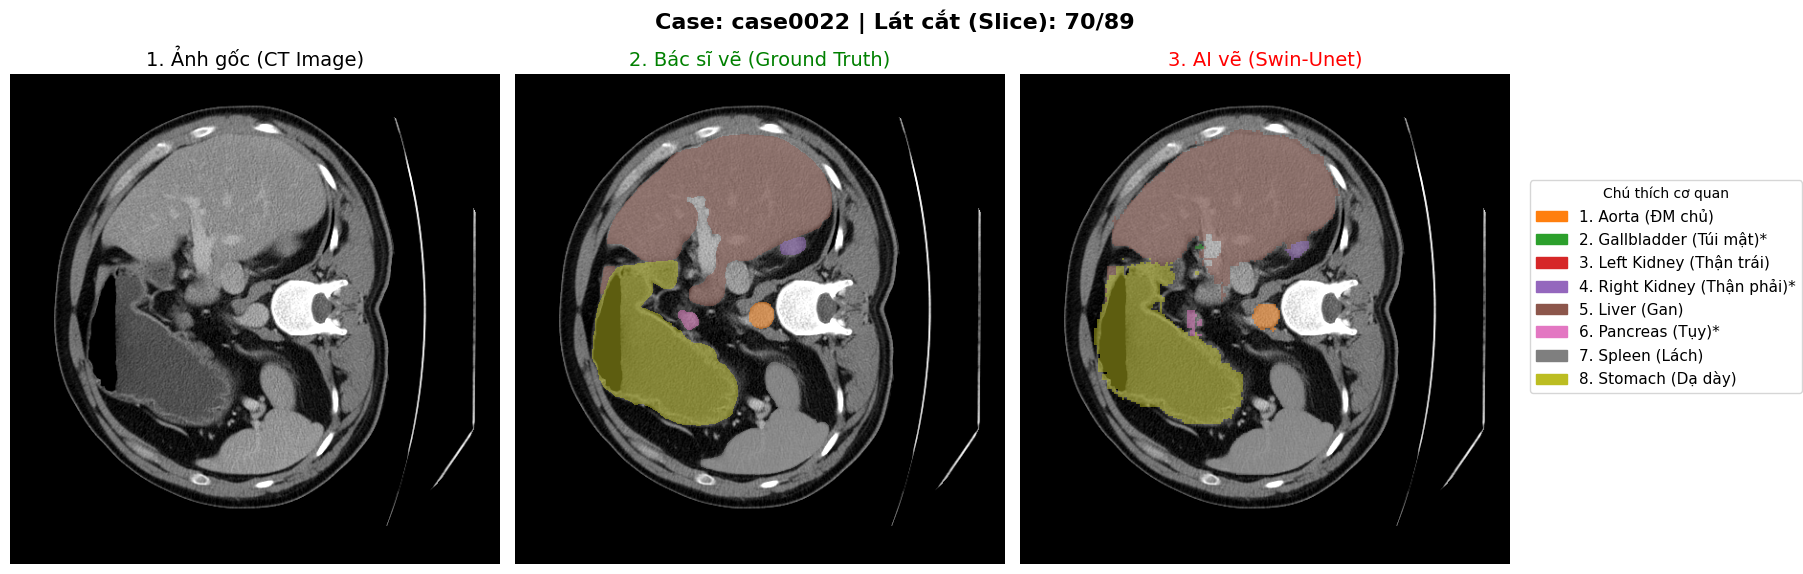

In [14]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Định nghĩa bảng màu và tên bộ phận (Synapse dataset)
label_names = {
    1: "Aorta (ĐM chủ)",
    2: "Gallbladder (Túi mật)*",
    3: "Left Kidney (Thận trái)",
    4: "Right Kidney (Thận phải)*",
    5: "Liver (Gan)",
    6: "Pancreas (Tụy)*",
    7: "Spleen (Lách)",
    8: "Stomach (Dạ dày)"
}

def print_pixel_stats(gt_slice, pred_slice):
    """Hàm in bảng thống kê pixel ra màn hình Terminal (Console)"""
    print("\n" + "="*60)
    print(f"📊 THỐNG KÊ SỐ PIXEL (LÁT CẮT HIỆN TẠI)")
    print("="*60)
    # Căn lề cho bảng đẹp mắt
    print(f"{'Cơ quan':<25} | {'Bác sĩ (GT)':<12} | {'AI (Pred)':<12} | {'Lệch':<10}")
    print("-" * 60)
    
    # Gộp tất cả các cơ quan xuất hiện trong cả 2 ảnh để đếm
    unique_classes = np.unique(np.concatenate((gt_slice, pred_slice)))
    
    for cls in unique_classes:
        if cls == 0:  # Bỏ qua nền đen (background)
            continue
        
        name = label_names.get(cls, f"C.{int(cls)}")
        gt_count = np.sum(gt_slice == cls)
        pred_count = np.sum(pred_slice == cls)
        
        # Tính độ lệch
        diff = pred_count - gt_count
        diff_str = f"+{diff}" if diff > 0 else str(diff)
        
        print(f"{name:<25} | {gt_count:<12} | {pred_count:<12} | {diff_str:<10}")
    print("="*60 + "\n")

def visualize_prediction(pred_dir, case_name, slice_idx=None):
    """
    Hàm hiển thị ảnh CT, Ground Truth và Prediction (chỉ hiển thị ảnh, không chèn chữ số).
    """
    img_path = os.path.join(pred_dir, f"{case_name}_img.nii.gz")
    gt_path = os.path.join(pred_dir, f"{case_name}_gt.nii.gz")
    pred_path = os.path.join(pred_dir, f"{case_name}_pred.nii.gz")

    if not all([os.path.exists(img_path), os.path.exists(gt_path), os.path.exists(pred_path)]):
        print(f"Lỗi: Không tìm thấy file cho case {case_name} trong {pred_dir}")
        return

    # Load file NIfTI
    img_sitk = sitk.ReadImage(img_path)
    gt_sitk = sitk.ReadImage(gt_path)
    pred_sitk = sitk.ReadImage(pred_path)

    # Chuyển đổi sang mảng Numpy
    img_np = sitk.GetArrayFromImage(img_sitk)
    
    # Ép kiểu về số nguyên để màu hiển thị chính xác
    gt_np = np.round(sitk.GetArrayFromImage(gt_sitk)).astype(np.int32)
    pred_np = np.round(sitk.GetArrayFromImage(pred_sitk)).astype(np.int32)

    # Tự động tìm lát cắt có nhiều nội tạng nhất nếu bạn để slice_idx=None
    if slice_idx is None:
        print("\nĐang quét khối 3D để tìm lát cắt đẹp nhất...")
        pixels_per_slice = [np.sum(gt_np[i] > 0) for i in range(gt_np.shape[0])]
        slice_idx = np.argmax(pixels_per_slice)
        print(f"-> Đã tự động chọn Lát cắt số: {slice_idx}")

    img_slice = img_np[slice_idx, :, :]
    gt_slice = gt_np[slice_idx, :, :]
    pred_slice = pred_np[slice_idx, :, :]

    # BƯỚC MỚI: Gọi hàm in bảng thống kê ra Terminal
    print_pixel_stats(gt_slice, pred_slice)

    # Khởi tạo bảng màu tab10
    cmap = plt.get_cmap('tab10')

    # Bắt đầu vẽ hình (Trả lại sự sạch sẽ cho hình ảnh)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Case: {case_name} | Lát cắt (Slice): {slice_idx}/{img_np.shape[0]}", fontsize=16, fontweight='bold')

    # 1. Ảnh gốc
    axes[0].imshow(img_slice, cmap='gray')
    axes[0].set_title("1. Ảnh gốc (CT Image)", fontsize=14)
    axes[0].axis('off')

    # 2. Ground Truth
    axes[1].imshow(img_slice, cmap='gray')
    gt_mask = np.ma.masked_where(gt_slice == 0, gt_slice) 
    axes[1].imshow(gt_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=10, interpolation='none')
    axes[1].set_title("2. Bác sĩ vẽ (Ground Truth)", fontsize=14, color='green')
    axes[1].axis('off')

    # 3. Prediction
    axes[2].imshow(img_slice, cmap='gray')
    pred_mask = np.ma.masked_where(pred_slice == 0, pred_slice)
    axes[2].imshow(pred_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=10, interpolation='none')
    
    # Kiểm tra xem AI vẽ có khớp 100% với Bác sĩ không để tô màu tiêu đề
    is_perfect = np.array_equal(gt_slice, pred_slice)
    title_color = 'blue' if is_perfect else 'red'
    
    axes[2].set_title("3. AI vẽ (Swin-Unet)", fontsize=14, color=title_color)
    axes[2].axis('off')

    # --- Tạo Legend chung bên phải ---
    unique_all = list(label_names.keys())
    patches = [mpatches.Patch(color=cmap(v/10.0), label=f"{v}. {label_names[v]}") for v in unique_all]
    fig.legend(handles=patches, loc='center right', borderaxespad=0.1, title="Chú thích cơ quan", fontsize=11)

    # Chừa 15% khoảng trống bên phải cho cái bảng chú thích màu
    plt.tight_layout(rect=[0, 0, 0.85, 1]) 
    plt.show()

if __name__ == "__main__":
    PREDICTION_DIR = "./model_out_v2/predictions" 
    TARGET_CASE = "case0022"
    
    # Bạn có thể đổi số 70 thành None nếu muốn nó tự quét lát cắt đẹp nhất
    visualize_prediction(PREDICTION_DIR, TARGET_CASE, slice_idx=70)

In [2]:
%pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 26.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.
